# **CAR PRICE PREDICTION MACHINE LEARNING PROJECT**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
FILE_PATH = "/content/drive/MyDrive/Veri Setleri/Makine Öğrenmesi Dersi/vehicles.csv"   # ← düzenle

df = pd.read_csv(FILE_PATH)

print(f"   Row  : {df.shape[0]:,}")
print(f"   Column  : {df.shape[1]}")

   Row  : 426,880
   Column  : 26


In [ ]:
print("=" * 55)
print("FIRST 5 ROWS")
print("=" * 55)
df.head()

FIRST 5 ROWS


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


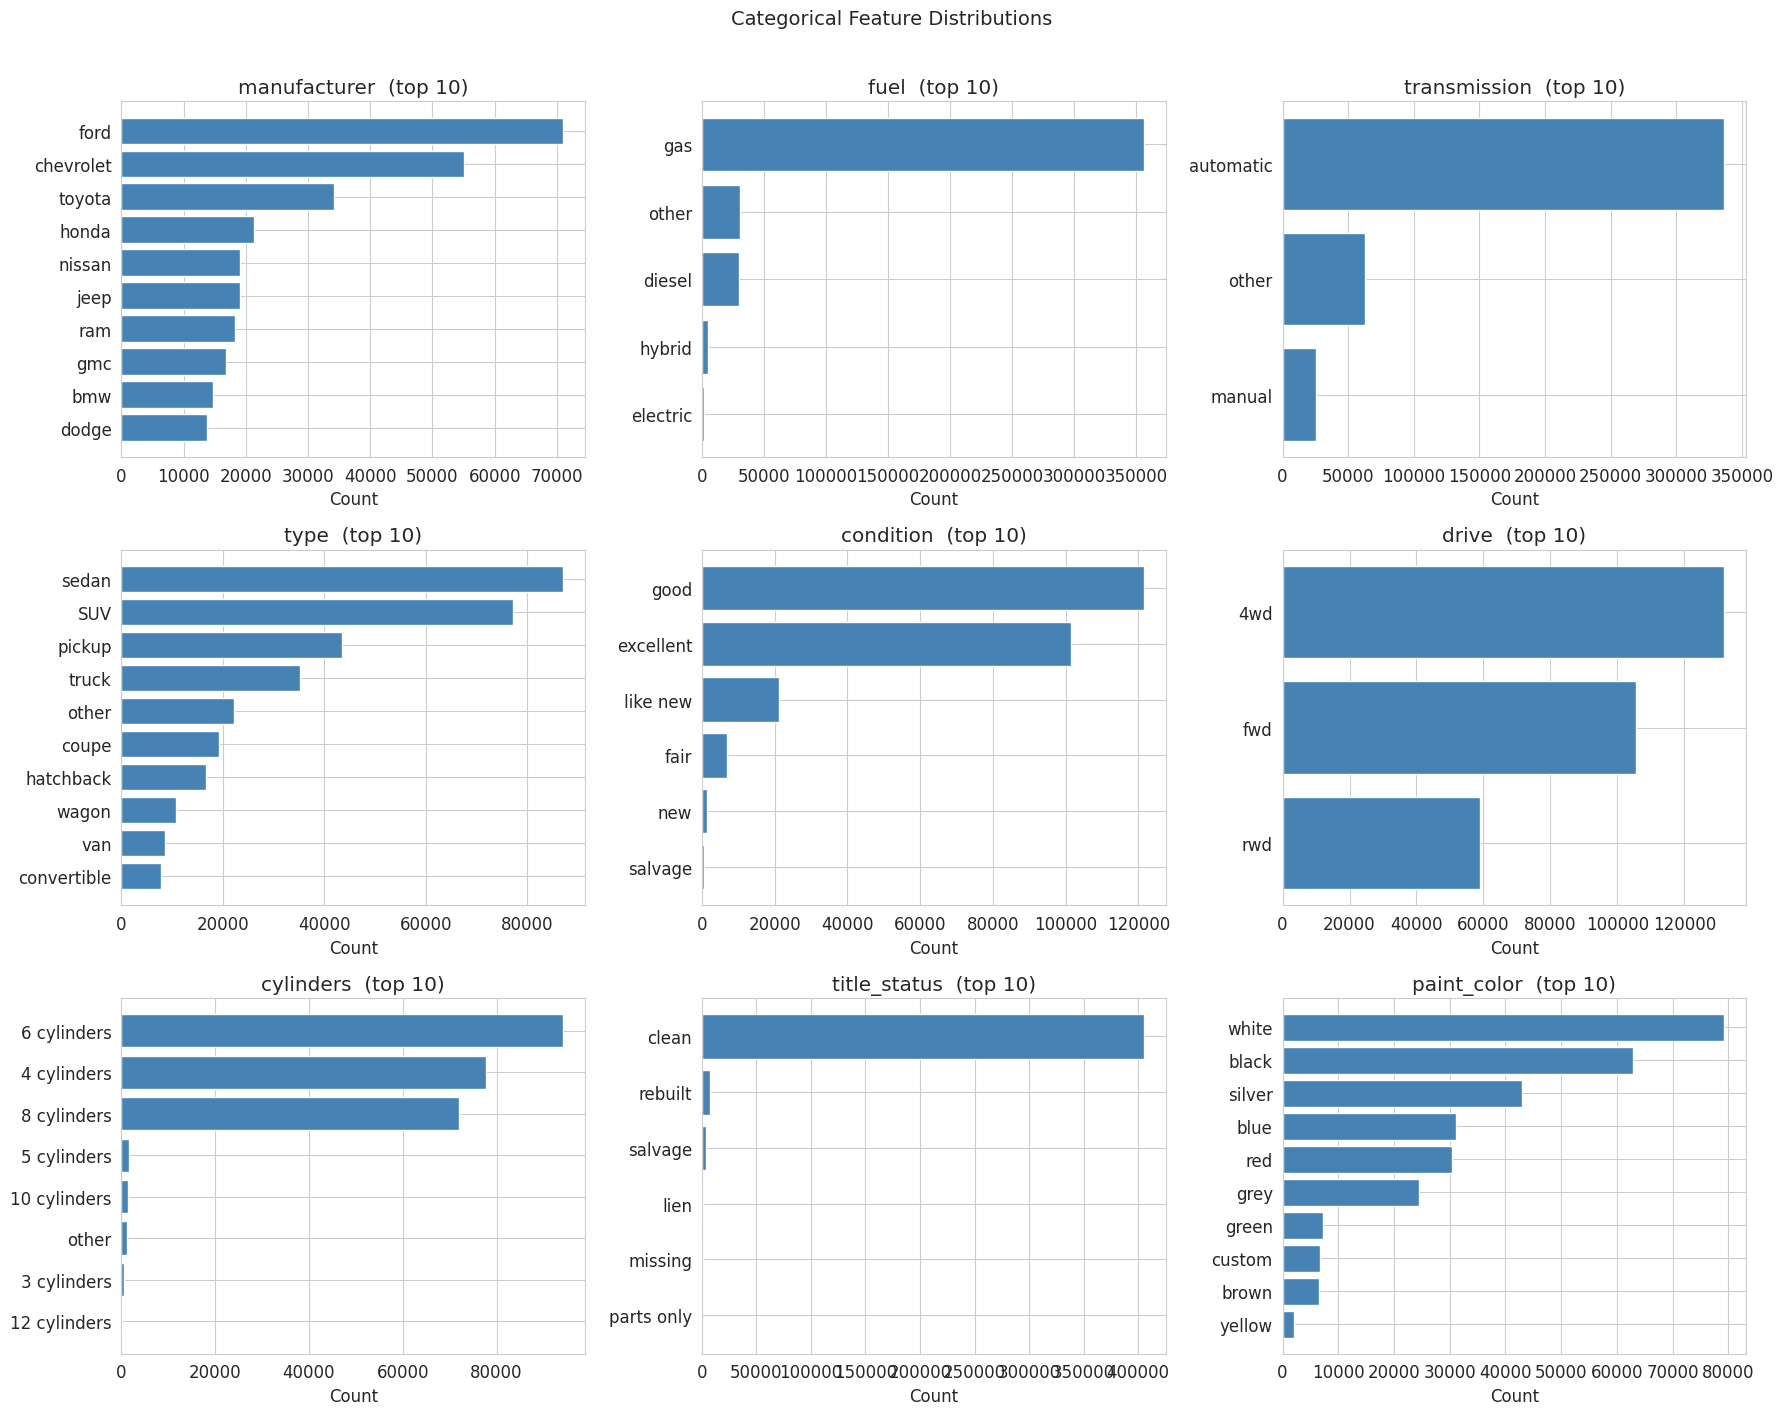

In [ ]:
cat_cols = ['manufacturer', 'fuel', 'transmission', 'type',
            'condition', 'drive', 'cylinders',
            'title_status', 'paint_color']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().head(10)
    axes[i].barh(counts.index[::-1], counts.values[::-1], color='steelblue')
    axes[i].set_title(f'{col}  (top 10)')
    axes[i].set_xlabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("COLUMN TYPES & NON-NULL COUNTS")
print("=" * 55)
df.info()

COLUMN TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334

There are 25 different categories.

**MISSING VALUES**

In [ ]:
missing = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print("=" * 55)
print("MISSING VALUES")
print("=" * 55)
print(missing[missing['missing_count'] > 0])

MISSING VALUES
              missing_count  missing_pct
county               426880       100.00
size                 306361        71.77
cylinders            177678        41.62
condition            174104        40.79
VIN                  161042        37.73
drive                130567        30.59
paint_color          130203        30.50
type                  92858        21.75
manufacturer          17646         4.13
title_status           8242         1.93
lat                    6549         1.53
long                   6549         1.53
model                  5277         1.24
odometer               4400         1.03
fuel                   3013         0.71
transmission           2556         0.60
year                   1205         0.28
description              70         0.02
posting_date             68         0.02
image_url                68         0.02


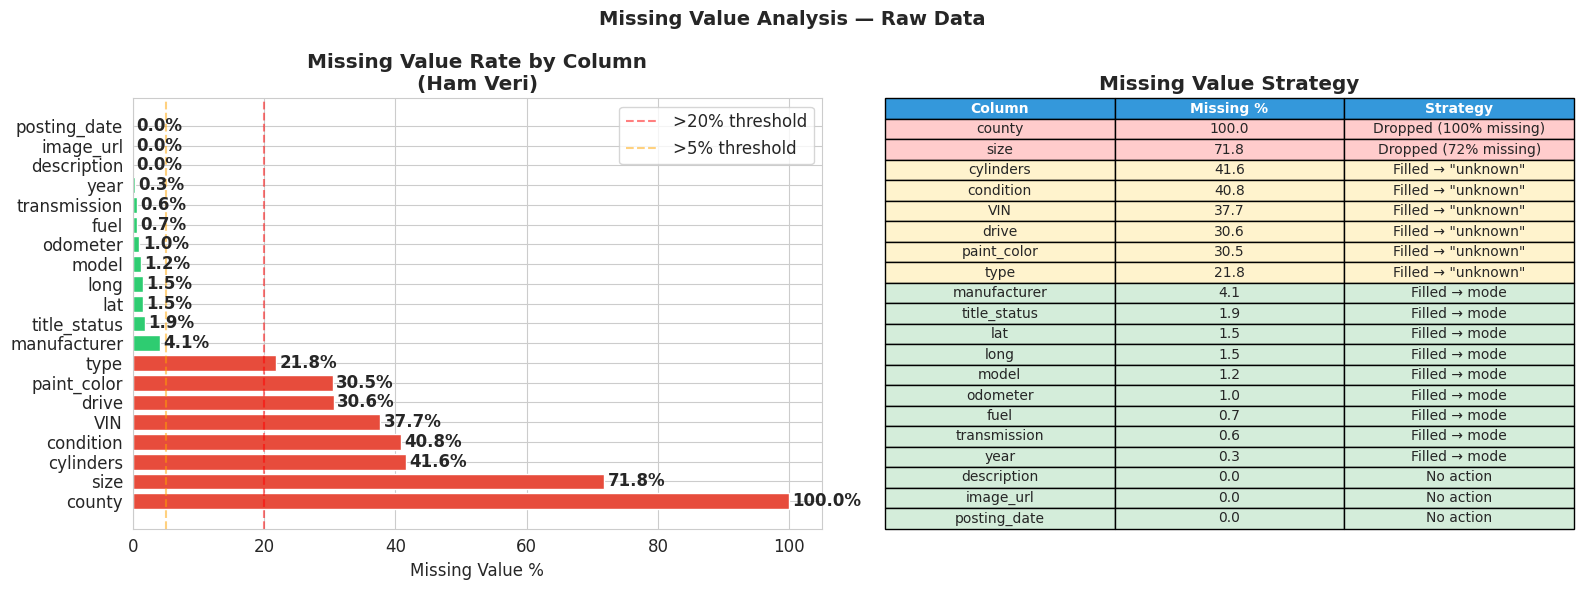

In [ ]:
# Ham veri üzerinde missing value analizi
missing_raw = df.isnull().sum()
missing_pct_raw = (missing_raw / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing_raw,
    'Missing %': missing_pct_raw
}).sort_values('Missing %', ascending=False)

# Sadece eksik değeri olan kolonlar
missing_df = missing_df[missing_df['Missing Count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Eksik değer yüzdesi
colors_missing = ['#e74c3c' if x > 20 else '#f39c12' if x > 5 else '#2ecc71'
                  for x in missing_df['Missing %']]

bars = axes[0].barh(missing_df.index, missing_df['Missing %'],
                     color=colors_missing, edgecolor='white')
axes[0].set_xlabel('Missing Value %')
axes[0].set_title('Missing Value Rate by Column\n(Ham Veri)', fontweight='bold')
axes[0].axvline(x=20, color='red', linestyle='--', alpha=0.5, label='>20% threshold')
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.5, label='>5% threshold')
axes[0].legend()

for bar, val in zip(bars, missing_df['Missing %']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontweight='bold')

# Sağ: Strateji tablosu
strategies = []
for col in missing_df.index:
    pct = missing_df.loc[col, 'Missing %']
    if col == 'county':
        strategies.append('Dropped (100% missing)')
    elif col == 'size':
        strategies.append('Dropped (72% missing)')
    elif pct > 20:
        strategies.append('Filled → "unknown"')
    elif pct > 0:
        strategies.append('Filled → mode')
    else:
        strategies.append('No action')

strategy_df = pd.DataFrame({
    'Column': missing_df.index,
    'Missing %': missing_df['Missing %'].values,
    'Strategy': strategies
})

axes[1].axis('off')
table = axes[1].table(
    cellText=strategy_df.values,
    colLabels=strategy_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)

# Renklendirme
for i, strategy in enumerate(strategies):
    if 'Dropped' in strategy:
        color = '#ffcccc'
    elif 'unknown' in strategy:
        color = '#fff3cd'
    else:
        color = '#d4edda'
    for j in range(3):
        table[(i+1, j)].set_facecolor(color)
    table[(i+1, 0)].set_facecolor(color)

table[(0,0)].set_facecolor('#3498db')
table[(0,1)].set_facecolor('#3498db')
table[(0,2)].set_facecolor('#3498db')
for j in range(3):
    table[(0,j)].set_text_props(color='white', fontweight='bold')

axes[1].set_title('Missing Value Strategy', fontweight='bold')

plt.suptitle('Missing Value Analysis — Raw Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

There's a lot of missing data. Specifically, the 'county' section is 100% empty. We'll drop these unnecessary features.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("=" * 55)
print("PRICE  ─  Basic Statistics")
print("=" * 55)
print(df['price'].describe())
print(f"\nZero-price rows   : {(df['price'] == 0).sum():,}")
print(f"Price > 1,000,000 : {(df['price'] > 1_000_000).sum():,}")

PRICE  ─  Basic Statistics
count         426,880.00
mean           75,199.03
std        12,182,282.17
min                 0.00
25%             5,900.00
50%            13,950.00
75%            26,485.75
max     3,736,928,711.00
Name: price, dtype: float64

Zero-price rows   : 32,895
Price > 1,000,000 : 53


- There are a total of 428,880 rows.

- The mean is very misleading because there are outliers pulling in.

- The standard deviation is 16 times greater than the mean. So the data is very scattered.

- Min 0, but the car can't be free, so it's a false/fake listing.

- 25% of the data is under $5,900.

- 50% (Median) Median price - much more reliable than the mean.

- 75% of the data is under $26,485.

- Max 3.7 billion, but clearly a flawed entry - not realistic.

The real problem here is the difference between Mean and Median:

- Mean: $75,199 ← outliers are pulling it up

- Median: $13,950 ← the actual "typical" price

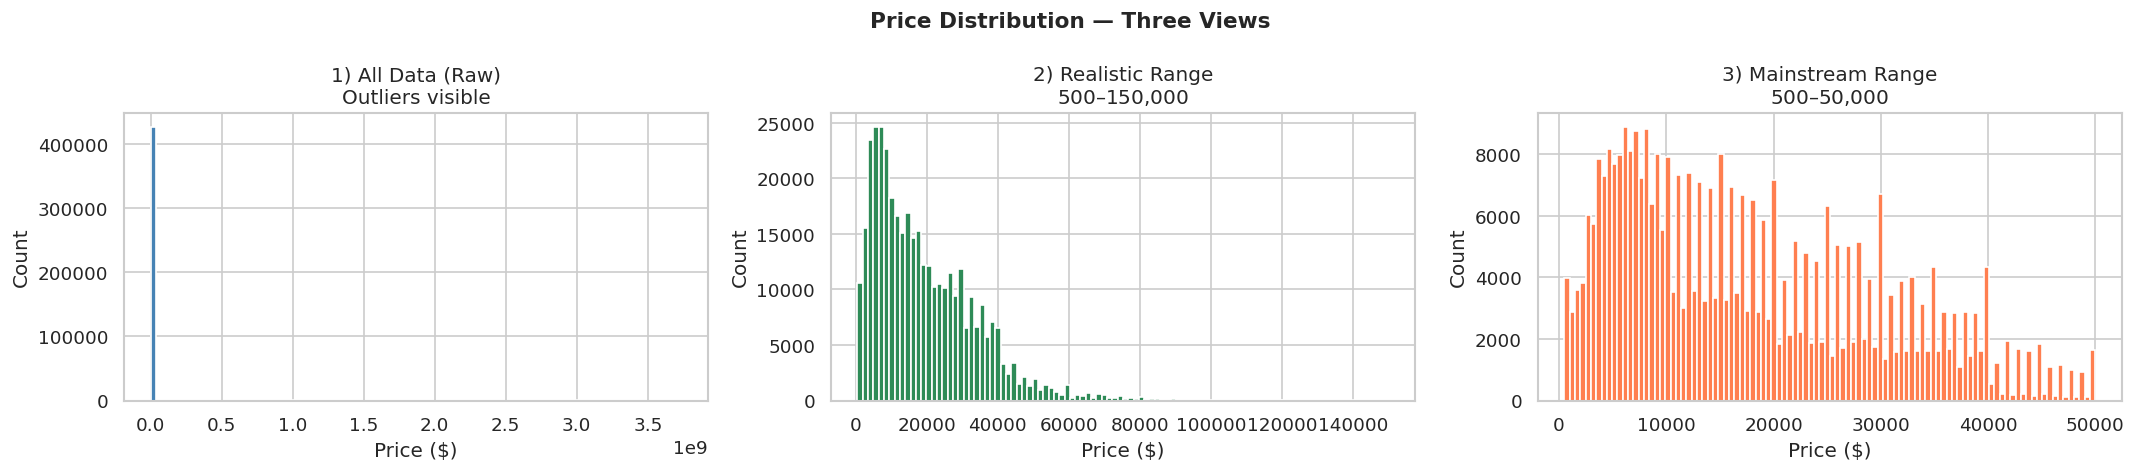

WHAT EACH VIEW SHOWS
  1) Raw data       :    426,880 rows  — outliers are visible
  2) $500–$150k     :    384,590 rows  — realistic car prices
  3) $500–$50k      :    371,850 rows  — busiest area

  Dropped (noise)   :     42,290 rows


In [ ]:
# ── Price distribution - 3 clear views
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) Raw data - all data (to see the outliers)
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('1) All Data (Raw)\nOutliers visible')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# 2) Realistic range - realistic car prices
realistic = df[(df['price'] >= 500) & (df['price'] <= 150_000)]['price']
axes[1].hist(realistic, bins=100, color='seagreen', edgecolor='white')
axes[1].set_title('2) Realistic Range\n$500 – $150,000')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')

# 3) Mainstream range - busiest area
mainstream = df[(df['price'] >= 500) & (df['price'] <= 50_000)]['price']
axes[2].hist(mainstream, bins=100, color='coral', edgecolor='white')
axes[2].set_title('3) Mainstream Range\n$500 – $50,000')
axes[2].set_xlabel('Price ($)')
axes[2].set_ylabel('Count')

plt.suptitle('Price Distribution — Three Views', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 55)
print("WHAT EACH VIEW SHOWS")
print("=" * 55)
print(f"  1) Raw data       : {len(df):>10,} rows  — outliers are visible")
print(f"  2) $500–$150k     : {len(realistic):>10,} rows  — realistic car prices")
print(f"  3) $500–$50k      : {len(mainstream):>10,} rows  — busiest area")
print(f"\n  Dropped (noise)   : {len(df) - len(realistic):>10,} rows")

1. graph → "When we look at the raw data, almost nothing can be selected because the $3.7 billion worth of listings distort the graph"

2. graph → "When we apply a realistic vehicle price range, the distribution emerges"

3. graph → "The vast majority of data is concentrated under $50,000"

In [ ]:
numeric_cols = ['price', 'year', 'odometer']

print("=" * 55)
print("NUMERIC FEATURES  ─  Descriptive Statistics")
print("=" * 55)
print(df[numeric_cols].describe().round(2))

NUMERIC FEATURES  ─  Descriptive Statistics
                 price       year      odometer
count       426,880.00 425,675.00    422,480.00
mean         75,199.03   2,011.24     98,043.33
std      12,182,282.17       9.45    213,881.50
min               0.00   1,900.00          0.00
25%           5,900.00   2,008.00     37,704.00
50%          13,950.00   2,013.00     85,548.00
75%          26,485.75   2,017.00    133,542.50
max   3,736,928,711.00   2,022.00 10,000,000.00


**Correlation Hetmap for Numeric Features**

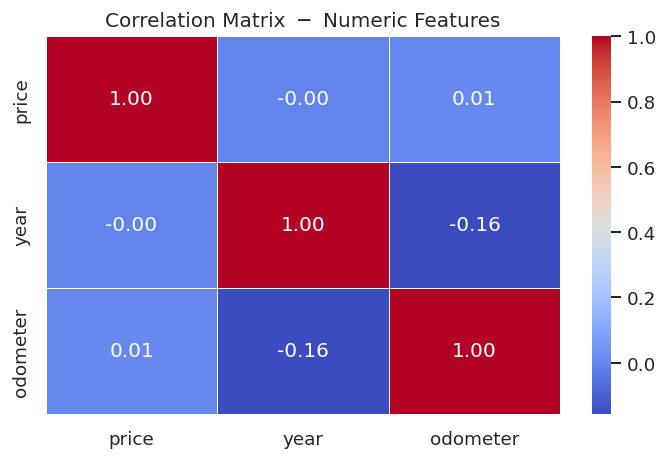

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix  ─  Numeric Features')
plt.tight_layout()
plt.show()

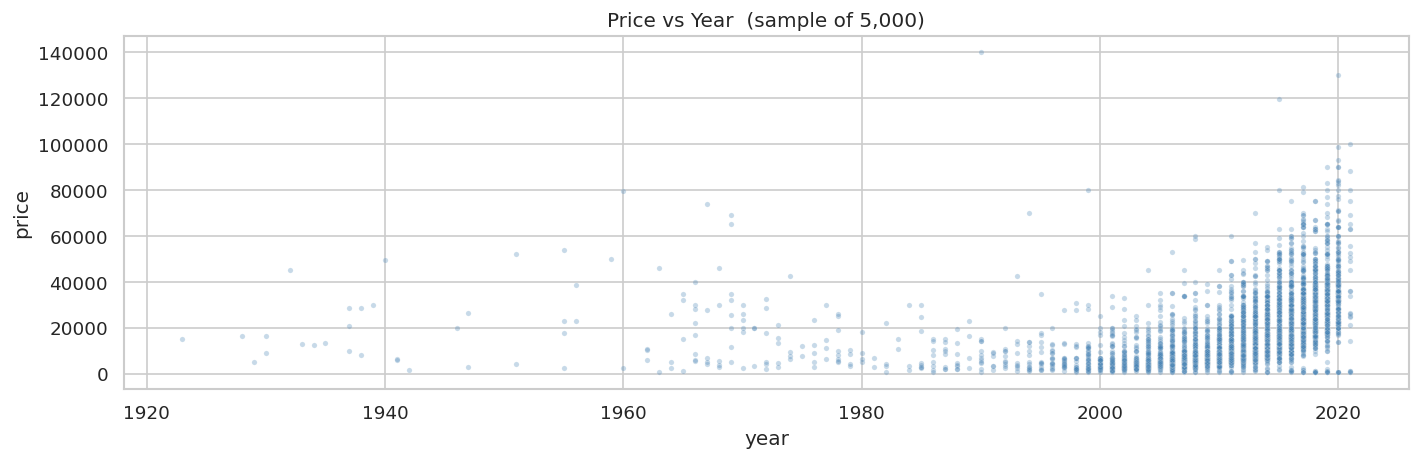

In [ ]:
# Quick filter just for visualization (not saved)
viz = df[(df['price'] > 500) & (df['price'] < 150_000)].copy()

# Price vs Year
plt.figure(figsize=(12, 4))
sns.scatterplot(data=viz.sample(5000, random_state=42),
                x='year', y='price', alpha=0.3, s=10, color='steelblue')
plt.title('Price vs Year  (sample of 5,000)')
plt.tight_layout()
plt.show()

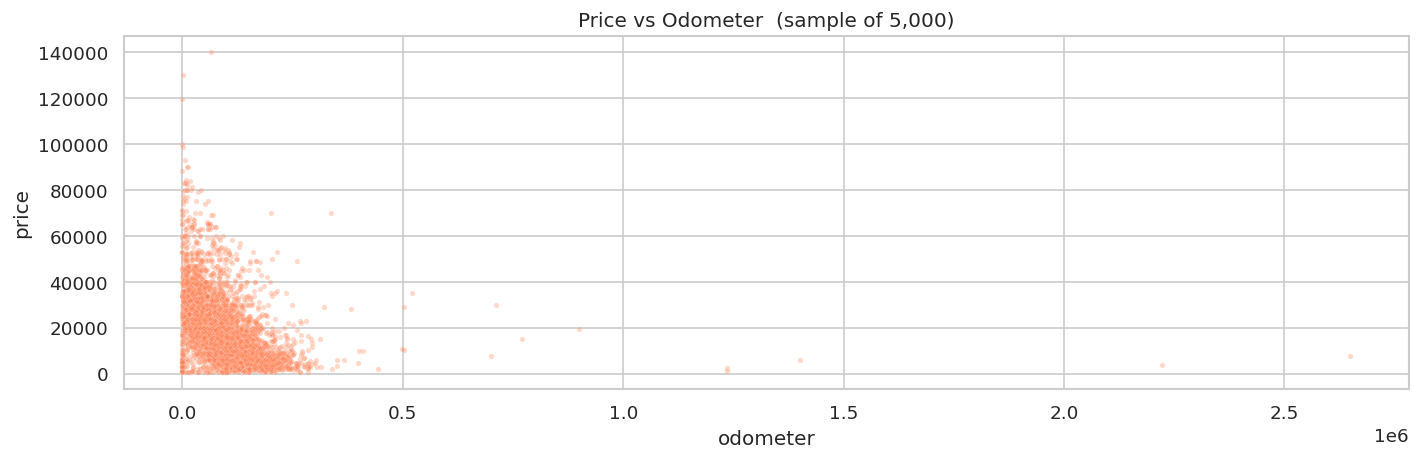

In [ ]:
# Price vs Odometer
plt.figure(figsize=(12, 4))
sns.scatterplot(data=viz.sample(5000, random_state=42),
                x='odometer', y='price', alpha=0.3, s=10, color='coral')
plt.title('Price vs Odometer  (sample of 5,000)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8291/3890329256.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz, x='condition', y='price',


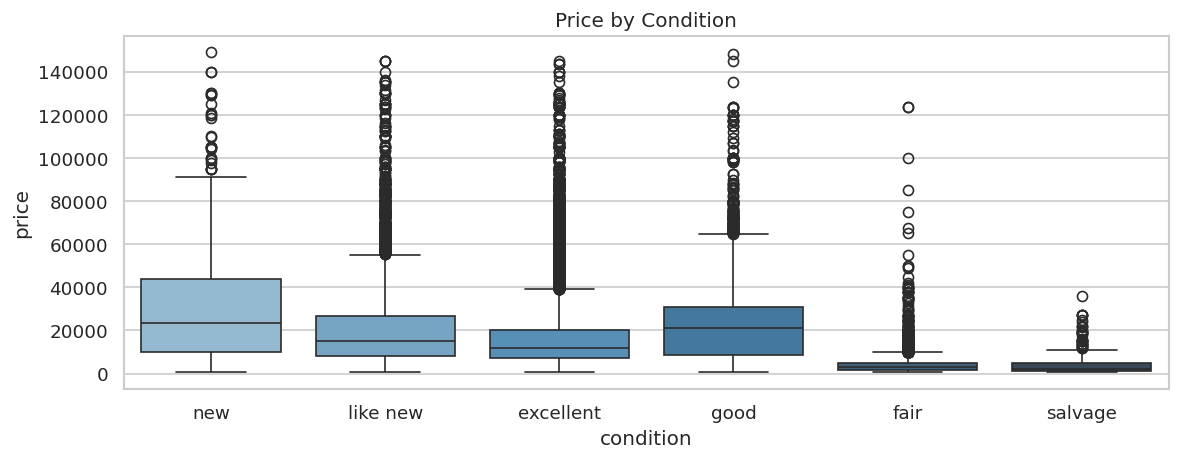

In [ ]:
# Price by condition
plt.figure(figsize=(10, 4))
order = ['new','like new','excellent','good','fair','salvage']
sns.boxplot(data=viz, x='condition', y='price',
            order=[o for o in order if o in viz['condition'].unique()],
            palette='Blues_d')
plt.title('Price by Condition')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8291/1379231971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz, x='fuel', y='price', palette='Set2')


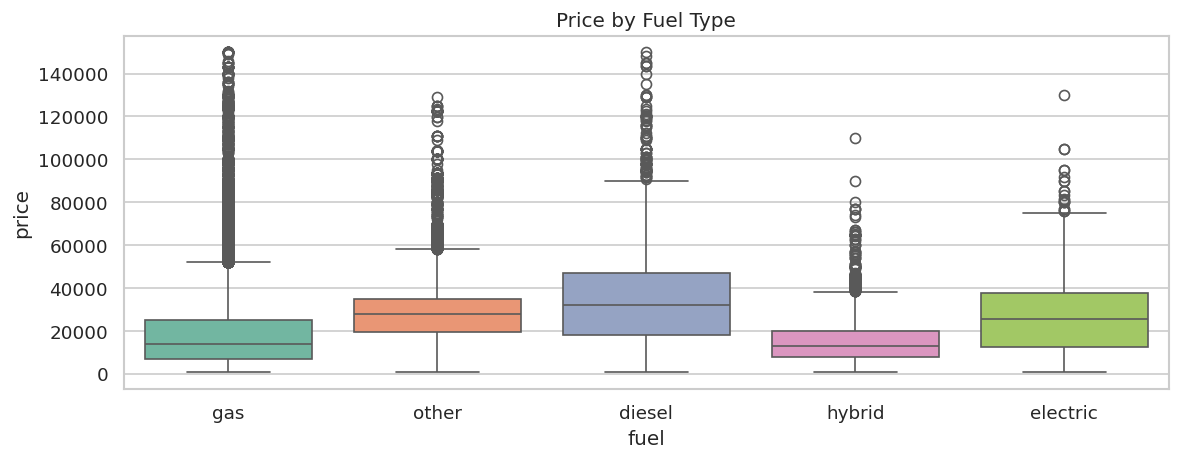

In [ ]:
# Price by fuel type
plt.figure(figsize=(10, 4))
sns.boxplot(data=viz, x='fuel', y='price', palette='Set2')
plt.title('Price by Fuel Type')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8291/1934644349.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz[viz['manufacturer'].isin(top_makes)],


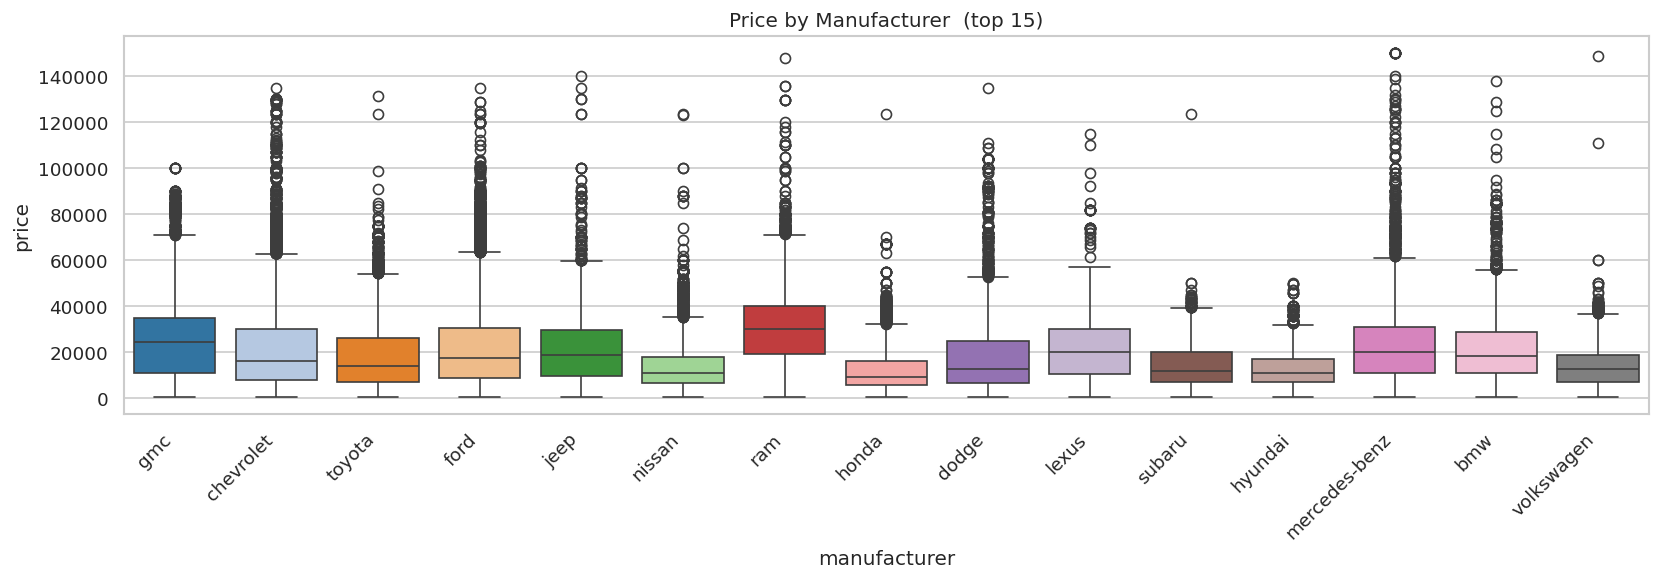

In [ ]:
# Price by top 15 manufacturers
top_makes = viz['manufacturer'].value_counts().head(15).index
plt.figure(figsize=(14, 5))
sns.boxplot(data=viz[viz['manufacturer'].isin(top_makes)],
            x='manufacturer', y='price', palette='tab20')
plt.xticks(rotation=45, ha='right')
plt.title('Price by Manufacturer  (top 15)')
plt.tight_layout()
plt.show()

## **DATA CLEANING**

In [ ]:
# Columns to be deleted

cols_to_drop = [
    'id',          # Unique identification number - meaningless for the model.
    'url',         # Advertisement URL
    'region_url',  # Region URL
    'image_url',   # Image URL
    'description', # Free text - We won't be doing NLP.
    'VIN',         # Vehicle identification number - virtually unique
    'county',      # %100 empty
    'size',        # %72 empty - cannot be saved
    'lat',         # Location coordinate
    'long',        # Location coordinate
    'posting_date',# Historical data - we're not using it for now.
    'region'       # The state already exists, the region is very granular.
]

df_clean = df.drop(columns=cols_to_drop)

print(f"Number of previous columns: {df.shape[1]}")
print(f"Next number of columns: {df_clean.shape[1]}")
print(f"\nRemaining columns:\n{df_clean.columns.tolist()}")

Number of previous columns: 26
Next number of columns: 14

Remaining columns:
['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


We are cleaning up the absurd values ​​we detected in EDA.

In [ ]:
print("=== BEFORE FILTER ===")
print(f"Number of Rows: {df_clean.shape[0]:,}")
print(f"Price  → min: {df_clean['price'].min():,}  |  max: {df_clean['price'].max():,}")
print(f"Year   → min: {df_clean['year'].min()}  |  max: {df_clean['year'].max()}")
print(f"Odometer → min: {df_clean['odometer'].min():,}  |  max: {df_clean['odometer'].max():,}")

# Apply filters
df_clean = df_clean[
    (df_clean['price']    >= 500)    & (df_clean['price']    <= 150_000) &
    (df_clean['year']     >= 1990)   & (df_clean['year']     <= 2022)    &
    (df_clean['odometer'] >= 0)      & (df_clean['odometer'] <= 300_000)
]

print("\n=== AFTER FILTER ===")
print(f"Number of Rows : {df_clean.shape[0]:,}")
print(f"Price  → min: {df_clean['price'].min():,}  |  max: {df_clean['price'].max():,}")
print(f"Year   → min: {df_clean['year'].min()}  |  max: {df_clean['year'].max()}")
print(f"Odometer → min: {df_clean['odometer'].min():,}  |  max: {df_clean['odometer'].max():,}")

# How much data did we lose?
lost = 426_880 - df_clean.shape[0]
lost_pct = lost / 426_880 * 100
print(f"\nNumber of lost lines: {lost:,}  ({lost_pct:.1f}%)")

=== BEFORE FILTER ===
Number of Rows: 426,880
Price  → min: 0  |  max: 3,736,928,711
Year   → min: 1900.0  |  max: 2022.0
Odometer → min: 0.0  |  max: 10,000,000.0

=== AFTER FILTER ===
Number of Rows : 367,218
Price  → min: 500  |  max: 150,000
Year   → min: 1990.0  |  max: 2022.0
Odometer → min: 0.0  |  max: 300,000.0

Number of lost lines: 59,662  (14.0%)


In [ ]:
print("=== MISSING VALUE ANALYSIS ===")
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(1)

missing_df = pd.DataFrame({
    'Number of Missing': missing,
    'Missing %': missing_pct,
    'Dtype': df_clean.dtypes
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Number of Missing'] > 0])

=== MISSING VALUE ANALYSIS ===
              Number of Missing  Missing %   Dtype
cylinders                151177      41.20  object
condition                139601      38.00  object
drive                    111021      30.20  object
paint_color              105337      28.70  object
type                      76651      20.90  object
manufacturer              11589       3.20  object
title_status               6474       1.80  object
model                      3387       0.90  object
fuel                       2108       0.60  object
transmission               1499       0.40  object


In [ ]:
# High deficiency → fill with 'unknown'
high_missing = ['cylinders', 'condition', 'drive', 'paint_color', 'type']
for col in high_missing:
    df_clean[col] = df_clean[col].fillna('unknown')

# Low deficiency → fill with mod
low_missing = ['manufacturer', 'title_status', 'model', 'fuel', 'transmission']
for col in low_missing:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

# Control
print("=== MISSING VALUE CHECK AFTER FILLING ===")
remaining = df_clean.isnull().sum().sum()
print(f"Total remaining missing value: {remaining}")
print(f"\nWas the row count preserved? {df_clean.shape[0]:,}")

=== MISSING VALUE CHECK AFTER FILLING ===
Total remaining missing value: 0

Was the row count preserved? 367,218


**Correlation Matrix Comparison After Data Cleaning**

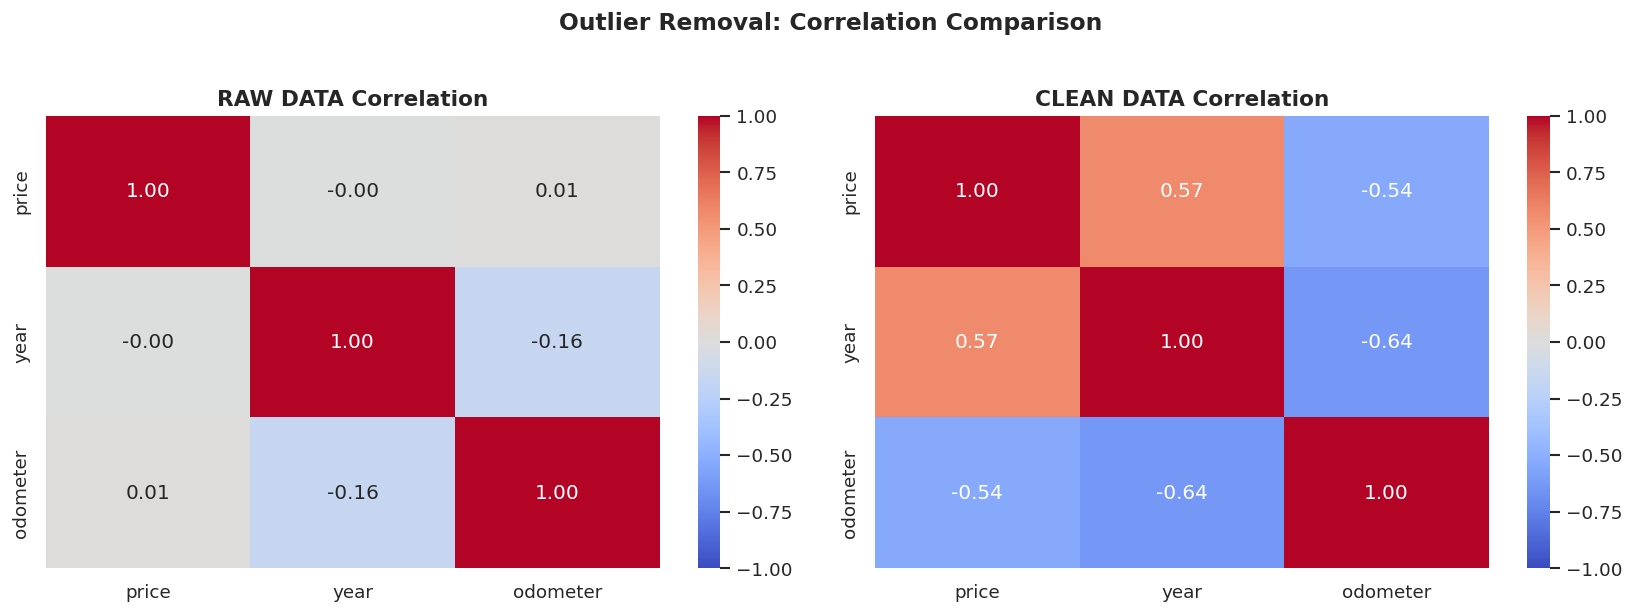


=== CORRELATION VALUES ===
RAW DATA:
year       -0.00
odometer    0.01

CLEAN DATA:
year        0.57
odometer   -0.54


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Numeric Columns
num_cols = ['price', 'year', 'odometer']

# Left → Correlation of raw data (original df)
corr_before = df[num_cols].corr()
sns.heatmap(corr_before, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('RAW DATA Correlation', fontsize=13, fontweight='bold')

# Right → Clean data correlation
corr_after = df_clean[num_cols].corr()
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('CLEAN DATA Correlation', fontsize=13, fontweight='bold')

plt.suptitle('Outlier Removal: Correlation Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('correlation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== CORRELATION VALUES ===")
print("RAW DATA:")
print(corr_before['price'].drop('price').to_string())
print("\nCLEAN DATA:")
print(corr_after['price'].drop('price').to_string())

## **FEATURE ENGINEERING**

In [ ]:
# 1. Vehicle age
df_clean['vehicle_age'] = 2024 - df_clean['year']

# 2. Annual average kilometers (rate of wear and tear)
df_clean['age_odometer_ratio'] = df_clean['odometer'] / (df_clean['vehicle_age'] + 1)

# 3. Luxury brand flag
luxury_brands = ['bmw', 'mercedes-benz', 'audi', 'lexus',
                 'porsche', 'jaguar', 'land rover', 'cadillac']
df_clean['is_luxury'] = df_clean['manufacturer'].isin(luxury_brands).astype(int)

# 4. Clean title flag
df_clean['is_clean_title'] = (df_clean['title_status'] == 'clean').astype(int)

# Kontrol
print("=== FEATURE ENGINEERING RESULT ===")
print(f"Number of new columns: {df_clean.shape[1]}")
print(f"\nNewly added columns:")
new_features = ['vehicle_age', 'age_odometer_ratio', 'is_luxury', 'is_clean_title']
print(df_clean[new_features].describe().round(2))

print(f"\nNumber of luxury vehicles   : {df_clean['is_luxury'].sum():,}  ({df_clean['is_luxury'].mean()*100:.1f}%)")
print(f"Number of clean title deeds  : {df_clean['is_clean_title'].sum():,}  ({df_clean['is_clean_title'].mean()*100:.1f}%)")

=== FEATURE ENGINEERING RESULT ===
Number of new columns: 18

Newly added columns:
       vehicle_age  age_odometer_ratio  is_luxury  is_clean_title
count   367,218.00          367,218.00 367,218.00      367,218.00
mean         11.70            7,068.07       0.13            0.97
std           5.81            3,913.01       0.33            0.18
min           2.00                0.00       0.00            0.00
25%           7.00            4,200.00       0.00            1.00
50%          11.00            6,898.08       0.00            1.00
75%          15.00            9,473.68       0.00            1.00
max          34.00           75,000.00       1.00            1.00

Number of luxury vehicles   : 46,394  (12.6%)
Number of clean title deeds  : 354,975  (96.7%)


In [ ]:
print("=== GENERAL CONDITION OF THE COLUMNS ===")
for col in df_clean.columns:
    dtype = df_clean[col].dtype
    n_unique = df_clean[col].nunique()
    print(f"{col:<25} dtype: {str(dtype):<10} unique: {n_unique:>6,}")

=== GENERAL CONDITION OF THE COLUMNS ===
price                     dtype: int64      unique: 14,861
year                      dtype: float64    unique:     33
manufacturer              dtype: object     unique:     41
model                     dtype: object     unique: 24,270
condition                 dtype: object     unique:      7
cylinders                 dtype: object     unique:      9
fuel                      dtype: object     unique:      5
odometer                  dtype: float64    unique: 94,612
title_status              dtype: object     unique:      6
transmission              dtype: object     unique:      3
drive                     dtype: object     unique:      4
type                      dtype: object     unique:     14
paint_color               dtype: object     unique:     13
state                     dtype: object     unique:     51
vehicle_age               dtype: float64    unique:     33
age_odometer_ratio        dtype: float64    unique: 122,924
is_luxury     

## **FEATURE SELECTION**

In [ ]:
# Coulmns to be deleted
cols_to_drop = ['year', 'title_status', 'model']

df_clean = df_clean.drop(columns=cols_to_drop)

print("=== FEATURE SELECTION RESULT ===")
print(f"Number of remaining columns: {df_clean.shape[1]}")
print(f"Remaining columns:\n{df_clean.columns.tolist()}")

=== FEATURE SELECTION RESULT ===
Number of remaining columns: 15
Remaining columns:
['price', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'transmission', 'drive', 'type', 'paint_color', 'state', 'vehicle_age', 'age_odometer_ratio', 'is_luxury', 'is_clean_title']


## **TRAIN/TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

# Separate the feature and target variables.
X = df_clean.drop(columns=['price'])
y = df_clean['price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("=== TRAIN/TEST SPLIT RESULT ===")
print(f"Total Data  : {len(df_clean):,}")
print(f"X_train      : {X_train.shape}")
print(f"X_test       : {X_test.shape}")
print(f"y_train      : {y_train.shape}")
print(f"y_test       : {y_test.shape}")

print(f"\n=== Target VARIABLE DISTRIBUTION ===")
print(f"y_train → mean: ${y_train.mean():,.0f}  |  median: ${y_train.median():,.0f}")
print(f"y_test  → mean: ${y_test.mean():,.0f}  |  median: ${y_test.median():,.0f}")

=== TRAIN/TEST SPLIT RESULT ===
Total Data  : 367,218
X_train      : (293774, 14)
X_test       : (73444, 14)
y_train      : (293774,)
y_test       : (73444,)

=== Target VARIABLE DISTRIBUTION ===
y_train → mean: $19,347  |  median: $15,990
y_test  → mean: $19,363  |  median: $15,990


## **NORMALIZATION**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Numeric columns to be scaled
num_cols = ['odometer', 'vehicle_age', 'age_odometer_ratio']

# Fit Scaler ONLY with training data!
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Apply ONLY the transform to the test data!
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("=== NORMALIZATION RESULT ===")
print("\nX_train numeric columns:")
print(X_train[num_cols].describe().round(3))

print("\nX_test numeric columns:")
print(X_test[num_cols].describe().round(3))

=== NORMALIZATION RESULT ===

X_train numeric columns:
        odometer  vehicle_age  age_odometer_ratio
count 293,774.00   293,774.00          293,774.00
mean       -0.00         0.00                0.00
std         1.00         1.00                1.00
min        -1.50        -1.67               -1.81
25%        -0.87        -0.81               -0.73
50%        -0.07        -0.12               -0.04
75%         0.70         0.57                0.61
max         3.34         3.83               17.37

X_test numeric columns:
       odometer  vehicle_age  age_odometer_ratio
count 73,444.00    73,444.00           73,444.00
mean      -0.00        -0.01                0.00
std        1.00         0.99                1.00
min       -1.50        -1.67               -1.81
25%       -0.87        -0.81               -0.73
50%       -0.07        -0.12               -0.04
75%        0.69         0.57                0.62
max        3.34         3.83               15.91


## **MODEL BUILDING**

**ONE-HOT ENCODING FOR LINEAR REGRESSION & LABEL ENCODING FOR RANDOM FOREST AND XGBOOST**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns
cat_cols = ['manufacturer', 'condition', 'cylinders', 'fuel',
            'transmission', 'drive', 'type', 'paint_color', 'state']

# FOR LINEAR REGRESSION → One-Hot Encoding
X_train_lr = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_lr  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

# Align the train and test columns (some categories may not be included in the test).
X_train_lr, X_test_lr = X_train_lr.align(X_test_lr, join='left', axis=1, fill_value=0)

# For RANDOM FOREST & XGBOOST → Label Encoding
X_train_tree = X_train.copy()
X_test_tree  = X_test.copy()

le = LabelEncoder()
for col in cat_cols:
    X_train_tree[col] = le.fit_transform(X_train_tree[col].astype(str))
    X_test_tree[col]  = le.transform(X_test_tree[col].astype(str))

# Check
print("=== ENCODING RESULT ===")
print(f"One-Hot (for Linear Regression):")
print(f"  X_train_lr shape : {X_train_lr.shape}")
print(f"  X_test_lr shape  : {X_test_lr.shape}")

print(f"\nLabel Encoded (For Tree models):")
print(f"  X_train_tree shape : {X_train_tree.shape}")
print(f"  X_test_tree shape  : {X_test_tree.shape}")

=== ENCODING RESULT ===
One-Hot (for Linear Regression):
  X_train_lr shape : (293774, 143)
  X_test_lr shape  : (73444, 143)

Label Encoded (For Tree models):
  X_train_tree shape : (293774, 14)
  X_test_tree shape  : (73444, 14)


### **LINEAR REGRESSION**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("=== LINEAR REGRESSION ===")
start = time.time()

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)

train_time = time.time() - start
print(f"Train duration: {train_time:.1f} seconds")

# Prediction
y_pred_lr = lr_model.predict(X_test_lr)

# Metrics
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"\nMAE  : ${mae_lr:,.0f}")
print(f"RMSE : ${rmse_lr:,.0f}")
print(f"R²   : {r2_lr:.4f}")

=== LINEAR REGRESSION ===
Train duration: 5.6 seconds

MAE  : $5,646
RMSE : $8,610
R²   : 0.6567


### **RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("=== RANDOM FOREST ===")
start = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100,    # 100 decision tree
    max_depth=15,        # Tree depth
    min_samples_leaf=5,  # Min sample per leaf
    n_jobs=-1,           # Use all CPUs
    random_state=42
)
rf_model.fit(X_train_tree, y_train)

train_time = time.time() - start
print(f"Train duration: {train_time:.1f} seconds")

# Prediction
y_pred_rf = rf_model.predict(X_test_tree)

# Metrics
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"\nMAE  : ${mae_rf:,.0f}")
print(f"RMSE : ${rmse_rf:,.0f}")
print(f"R²   : {r2_rf:.4f}")

=== RANDOM FOREST ===
Train duration: 149.4 seconds

MAE  : $3,439
RMSE : $6,078
R²   : 0.8289


### **XGBOOST**

In [ ]:
from xgboost import XGBRegressor

print("=== XGBOOST ===")
start = time.time()

xgb_model = XGBRegressor(
    n_estimators=300,      # 300 boosting round
    learning_rate=0.05,    # Step size
    max_depth=6,           # Each tree depth
    subsample=0.8,         # Data ratio in each tree
    colsample_bytree=0.8,  # Feature ratio in each tree
    min_child_weight=5,    # Min leaf weight
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train_tree, y_train,
    eval_set=[(X_test_tree, y_test)],
    verbose=False
)

train_time = time.time() - start
print(f"Train duration: {train_time:.1f} seconds")

# Prediction
y_pred_xgb = xgb_model.predict(X_test_tree)

# Metrics
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"\nMAE  : ${mae_xgb:,.0f}")
print(f"RMSE : ${rmse_xgb:,.0f}")
print(f"R²   : {r2_xgb:.4f}")

=== XGBOOST ===
Train duration: 14.1 seconds

MAE  : $3,878
RMSE : $6,551
R²   : 0.8013


**Hyperparameter Tuning for XGBoost**

In [ ]:
from xgboost import XGBRegressor

print("=== XGBOOST v2 - TUNED ===")
start = time.time()

xgb_model_v2 = XGBRegressor(
    n_estimators=500,      # 300 → 500
    learning_rate=0.02,    # 0.05 → 0.02 (smaller step)
    max_depth=7,           # 6 → 7 (a little deeper)
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,    # 5 → 3
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_model_v2.fit(
    X_train_tree, y_train,
    eval_set=[(X_test_tree, y_test)],
    verbose=False
)

train_time = time.time() - start
print(f"Train duration: {train_time:.1f} seconds")

y_pred_xgb_v2 = xgb_model_v2.predict(X_test_tree)

mae_xgb_v2  = mean_absolute_error(y_test, y_pred_xgb_v2)
rmse_xgb_v2 = np.sqrt(mean_squared_error(y_test, y_pred_xgb_v2))
r2_xgb_v2   = r2_score(y_test, y_pred_xgb_v2)

print(f"\nMAE  : ${mae_xgb_v2:,.0f}")
print(f"RMSE : ${rmse_xgb_v2:,.0f}")
print(f"R²   : {r2_xgb_v2:.4f}")

print(f"\nv1 vs v2:")
print(f"R²  → {r2_xgb:.4f} → {r2_xgb_v2:.4f}")
print(f"MAE → ${mae_xgb:,.0f} → ${mae_xgb_v2:,.0f}")

=== XGBOOST v2 - TUNED ===
Train duration: 26.2 seconds

MAE  : $3,803
RMSE : $6,437
R²   : 0.8081

v1 vs v2:
R²  → 0.8013 → 0.8081
MAE → $3,878 → $3,803


## **EVALUATION**

=== MODEL COMPARISON TABLE ===
            Model      MAE     RMSE   R²
Linear Regression 5,646.02 8,609.94 0.66
    Random Forest 3,438.85 6,077.85 0.83
       XGBoost v2 3,803.07 6,437.39 0.81


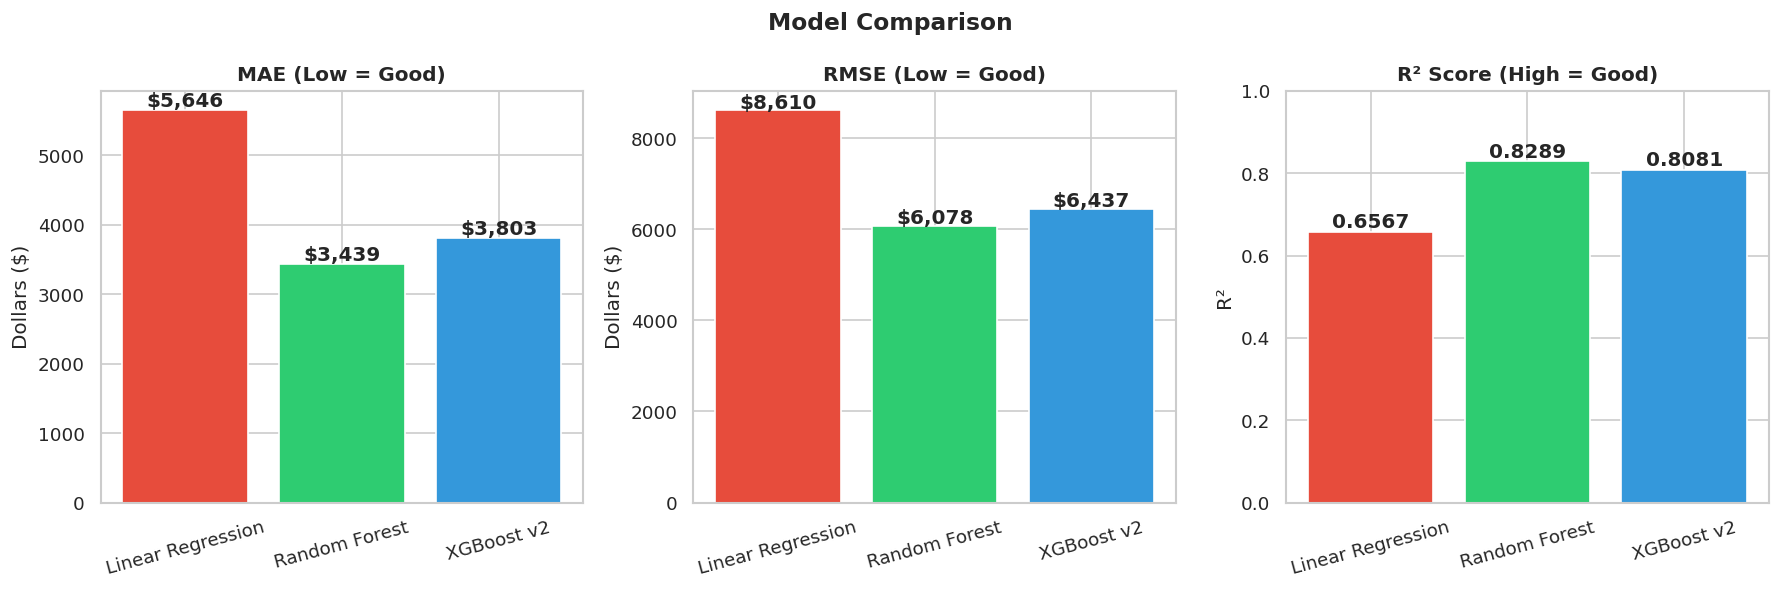

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sonuçları topla
results = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost v2'],
    'MAE':   [mae_lr, mae_rf, mae_xgb_v2],
    'RMSE':  [rmse_lr, rmse_rf, rmse_xgb_v2],
    'R²':    [r2_lr, r2_rf, r2_xgb_v2]
}
results_df = pd.DataFrame(results)

print("=== MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))

# visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#e74c3c', '#2ecc71', '#3498db']
models = results['Model']

# MAE
axes[0].bar(models, results['MAE'], color=colors)
axes[0].set_title('MAE (Low = Good)', fontweight='bold')
axes[0].set_ylabel('Dollars ($)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(results['MAE']):
    axes[0].text(i, v + 50, f'${v:,.0f}', ha='center', fontweight='bold')

# RMSE
axes[1].bar(models, results['RMSE'], color=colors)
axes[1].set_title('RMSE (Low = Good)', fontweight='bold')
axes[1].set_ylabel('Dollars ($)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(results['RMSE']):
    axes[1].text(i, v + 50, f'${v:,.0f}', ha='center', fontweight='bold')

# R²
axes[2].bar(models, results['R²'], color=colors)
axes[2].set_title('R² Score (High = Good)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(results['R²']):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Actual vs Predicted Plot**

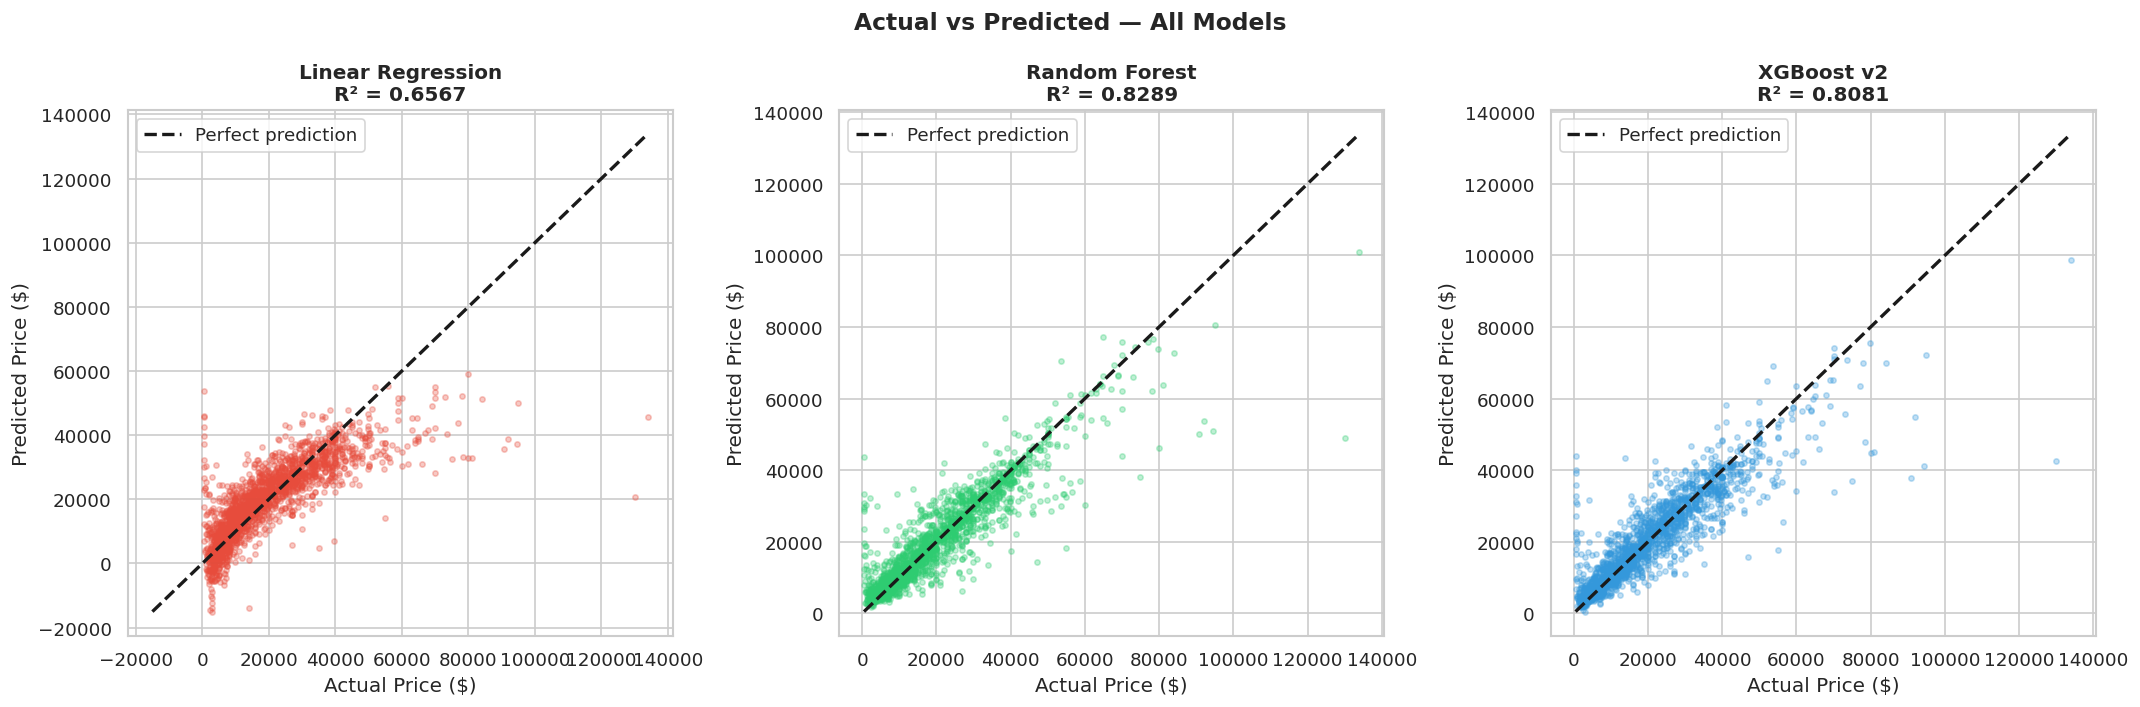

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_info = [
    ('Linear Regression', y_pred_lr,    r2_lr,    '#e74c3c'),
    ('Random Forest',     y_pred_rf,    r2_rf,    '#2ecc71'),
    ('XGBoost v2',        y_pred_xgb_v2, r2_xgb_v2, '#3498db')
]

# Take a sample (73k points is too many)
sample_idx = np.random.choice(len(y_test), 2000, replace=False)
y_test_sample = np.array(y_test)[sample_idx]

for ax, (name, y_pred, r2, color) in zip(axes, models_info):
    y_pred_sample = np.array(y_pred)[sample_idx]

    ax.scatter(y_test_sample, y_pred_sample,
               alpha=0.3, color=color, s=10)

    # Perfect prediction line
    min_val = min(y_test_sample.min(), y_pred_sample.min())
    max_val = max(y_test_sample.max(), y_pred_sample.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', lw=2, label='Perfect prediction')

    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature Importance**

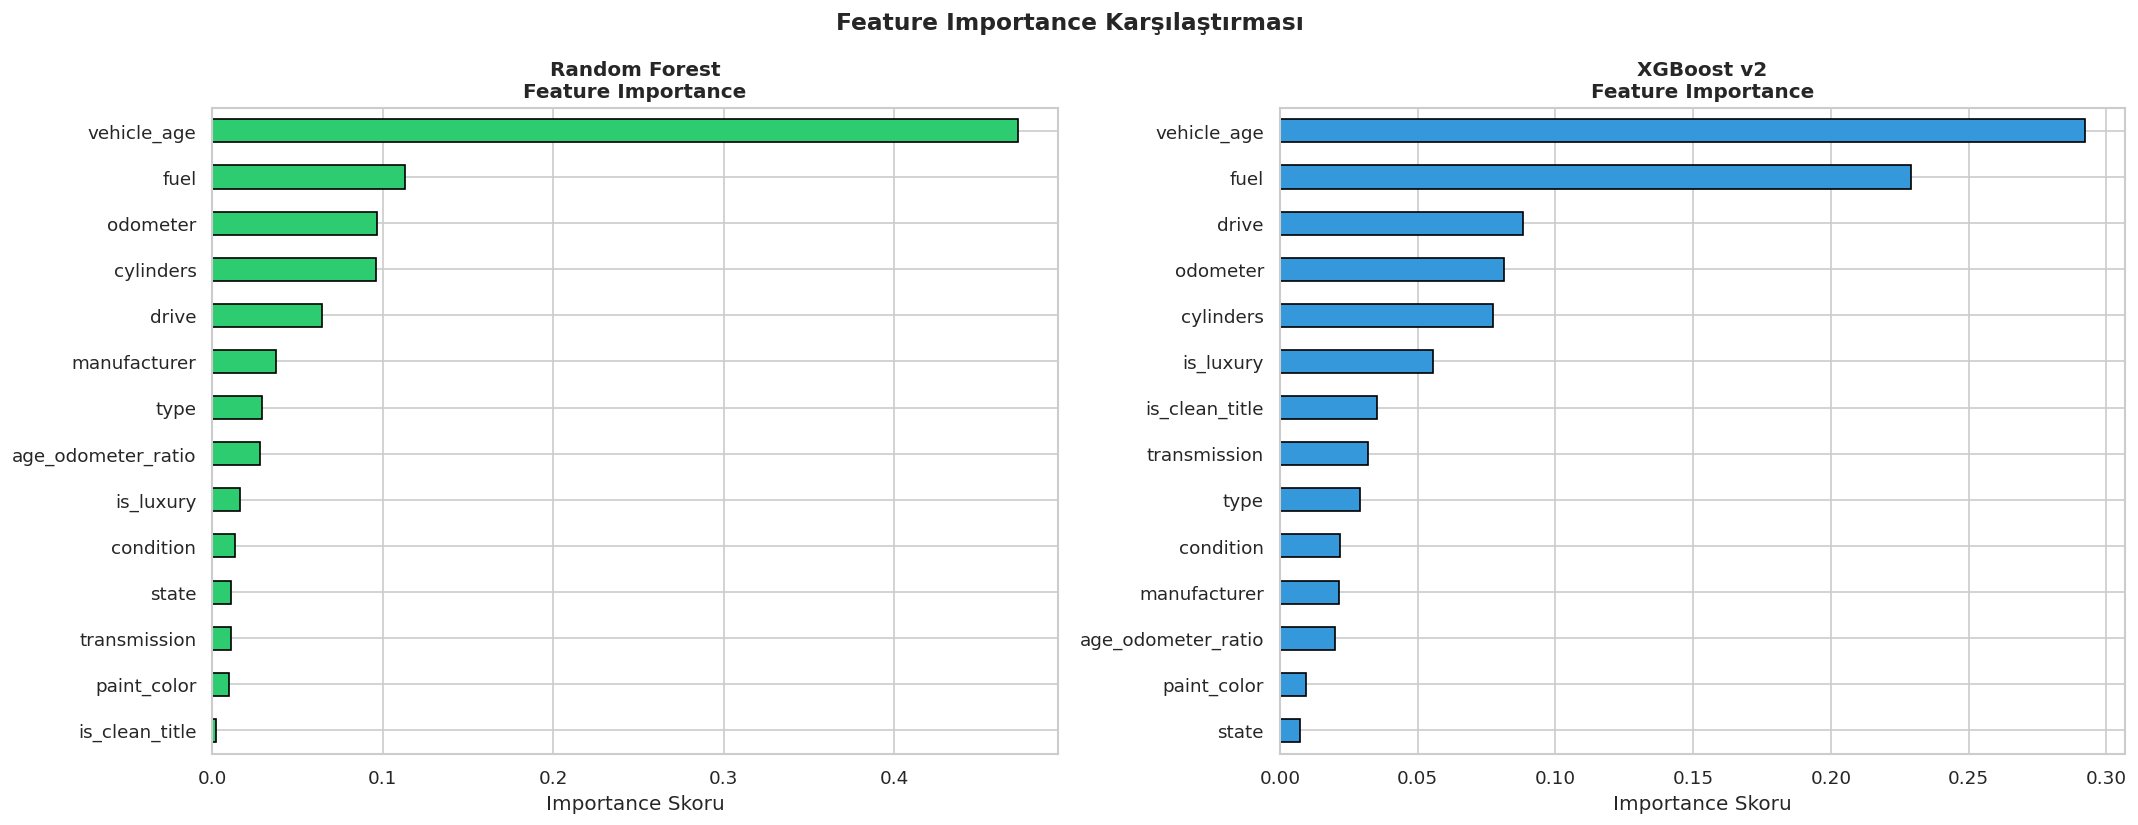


=== RANDOM FOREST — TOP 5 ===
vehicle_age   0.47
fuel          0.11
odometer      0.10
cylinders     0.10
drive         0.06
dtype: float64

=== XGBOOST — TOP 5 ===
vehicle_age   0.29
fuel          0.23
drive         0.09
odometer      0.08
cylinders     0.08
dtype: float32


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

feature_names = X_train_tree.columns.tolist()

# Random Forest Feature Importance
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

rf_importance.plot(kind='barh', ax=axes[0],
                   color='#2ecc71', edgecolor='black')
axes[0].set_title('Random Forest\nFeature Importance',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Importance Skoru')

# XGBoost Feature Importance
xgb_importance = pd.Series(
    xgb_model_v2.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

xgb_importance.plot(kind='barh', ax=axes[1],
                    color='#3498db', edgecolor='black')
axes[1].set_title('XGBoost v2\nFeature Importance',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance Skoru')

plt.suptitle('Feature Importance Karşılaştırması',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Sayısal değerler
print("\n=== RANDOM FOREST — TOP 5 ===")
print(rf_importance.sort_values(ascending=False).head())
print("\n=== XGBOOST — TOP 5 ===")
print(xgb_importance.sort_values(ascending=False).head())

## **SHAP ANALYSIS**

In [ ]:
import shap

print("Calculating SHAP values...")
print("(This may take a while, ~2-3 minutes)")

# TreeExplainer for RF (optimized for tree models)
explainer = shap.TreeExplainer(rf_model)

# Get 1000 samples (takes too long for 293k rows)
sample_idx = np.random.choice(len(X_train_tree), 1000, replace=False)
X_sample = X_train_tree.iloc[sample_idx]

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

print(f"SHAP calculated!")
print(f"shap_values ​​shape: {shap_values.shape}")
print(f"X_sample shape : {X_sample.shape}")

Calculating SHAP values...
(This may take a while, ~2-3 minutes)
SHAP calculated!
shap_values ​​shape: (1000, 14)
X_sample shape : (1000, 14)


**Summary Plot (Beeswarm):**

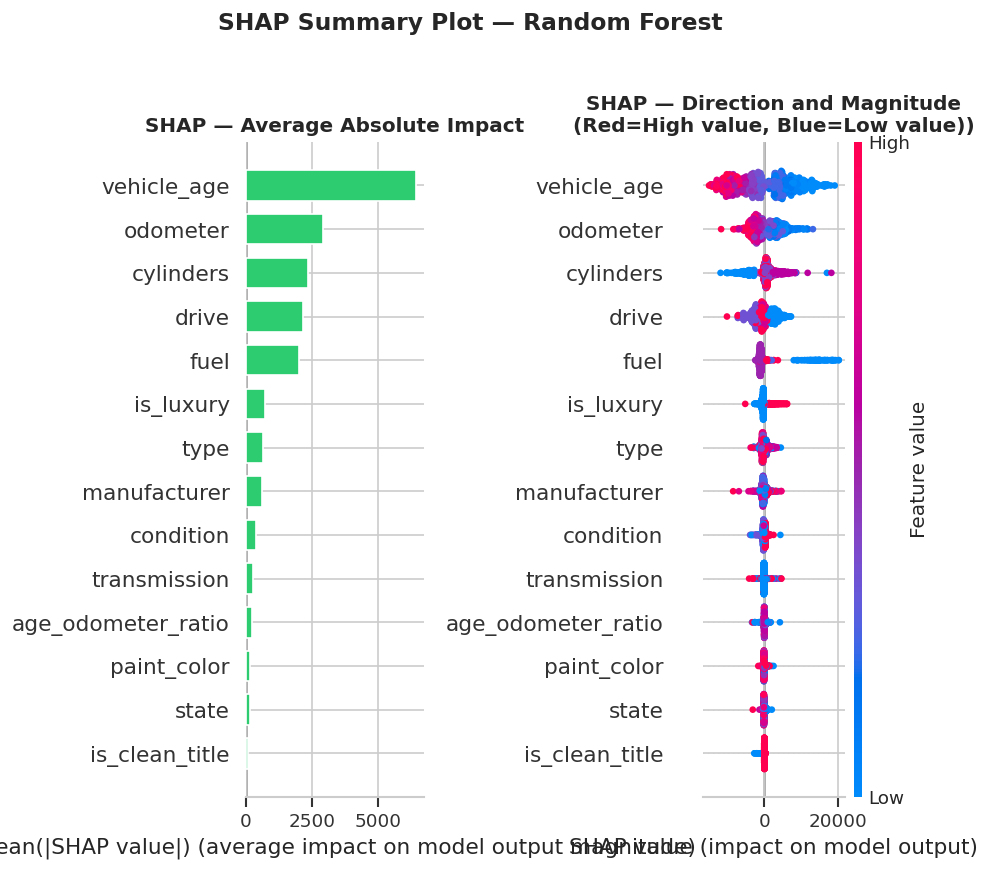


=== AVERAGE ABSOLUTE SHAPE VALUES ===
           Feature  SHAP_importance
       vehicle_age         6,408.42
          odometer         2,906.52
         cylinders         2,364.24
             drive         2,181.21
              fuel         2,000.33
         is_luxury           744.92
              type           656.45
      manufacturer           608.34
         condition           376.20
      transmission           283.10
age_odometer_ratio           235.54
       paint_color           177.54
             state           175.74
    is_clean_title            88.93


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Left: Bar plot (average effect) ---
plt.sca(axes[0])
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False,
    color='#2ecc71'
)
axes[0].set_title('SHAP — Average Absolute Impact',
                  fontweight='bold', fontsize=12)

# --- Right: Beeswarm (direction + size) ---
plt.sca(axes[1])
shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)
axes[1].set_title('SHAP — Direction and Magnitude\n(Red=High value, Blue=Low value))',
                  fontweight='bold', fontsize=12)

plt.suptitle('SHAP Summary Plot — Random Forest',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Numeric SHAP values
print("\n=== AVERAGE ABSOLUTE SHAPE VALUES ===")
shap_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'SHAP_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_importance', ascending=False)
print(shap_importance.to_string(index=False))

**Prediction Error Distribution**

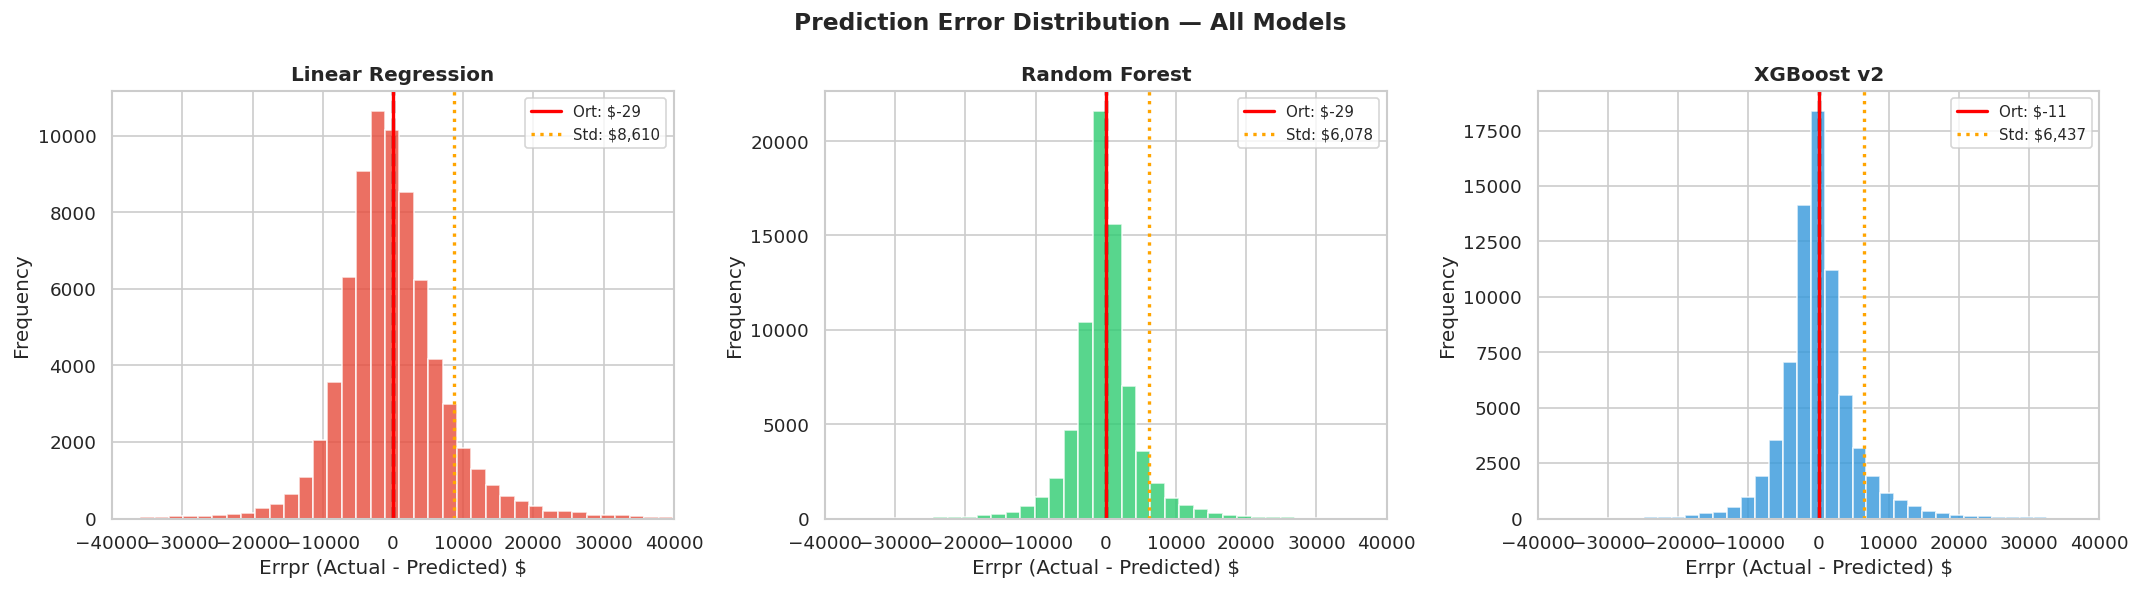

=== ERROR STATISTICS ===

Linear Regression:
  Average error : $-29
  Std           : $8,610
  95% range    : $-13,929 - $18,106

Random Forest:
  Average error : $-29
  Std           : $6,078
  95% range    : $-10,442 - $11,916

XGBoost v2:
  Average error : $-11
  Std           : $6,437
  95% range    : $-10,624 - $13,140


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Linear Regression', y_pred_lr,     '#e74c3c'),
    ('Random Forest',     y_pred_rf,     '#2ecc71'),
    ('XGBoost v2',        y_pred_xgb_v2, '#3498db')
]

y_test_arr = np.array(y_test)

for ax, (name, y_pred, color) in zip(axes, models_info):
    errors = y_test_arr - np.array(y_pred)

    ax.hist(errors, bins=100, color=color,
            edgecolor='white', alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='--', lw=2)
    ax.axvline(x=errors.mean(), color='red',
               linestyle='-', lw=2,
               label=f'Ort: ${errors.mean():,.0f}')
    ax.axvline(x=errors.std(), color='orange',
               linestyle=':', lw=2,
               label=f'Std: ${errors.std():,.0f}')

    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Errpr (Actual - Predicted) $')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

    # Limit the x-axis.
    ax.set_xlim(-40000, 40000)

plt.suptitle('Prediction Error Distribution — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ERROR STATISTICS ===")
for name, y_pred, _ in models_info:
    errors = y_test_arr - np.array(y_pred)
    print(f"\n{name}:")
    print(f"  Average error : ${errors.mean():,.0f}")
    print(f"  Std           : ${errors.std():,.0f}")
    print(f"  95% range    : ${np.percentile(errors,2.5):,.0f} - ${np.percentile(errors,97.5):,.0f}")

**Price Distribution: Actual vs Predicted**

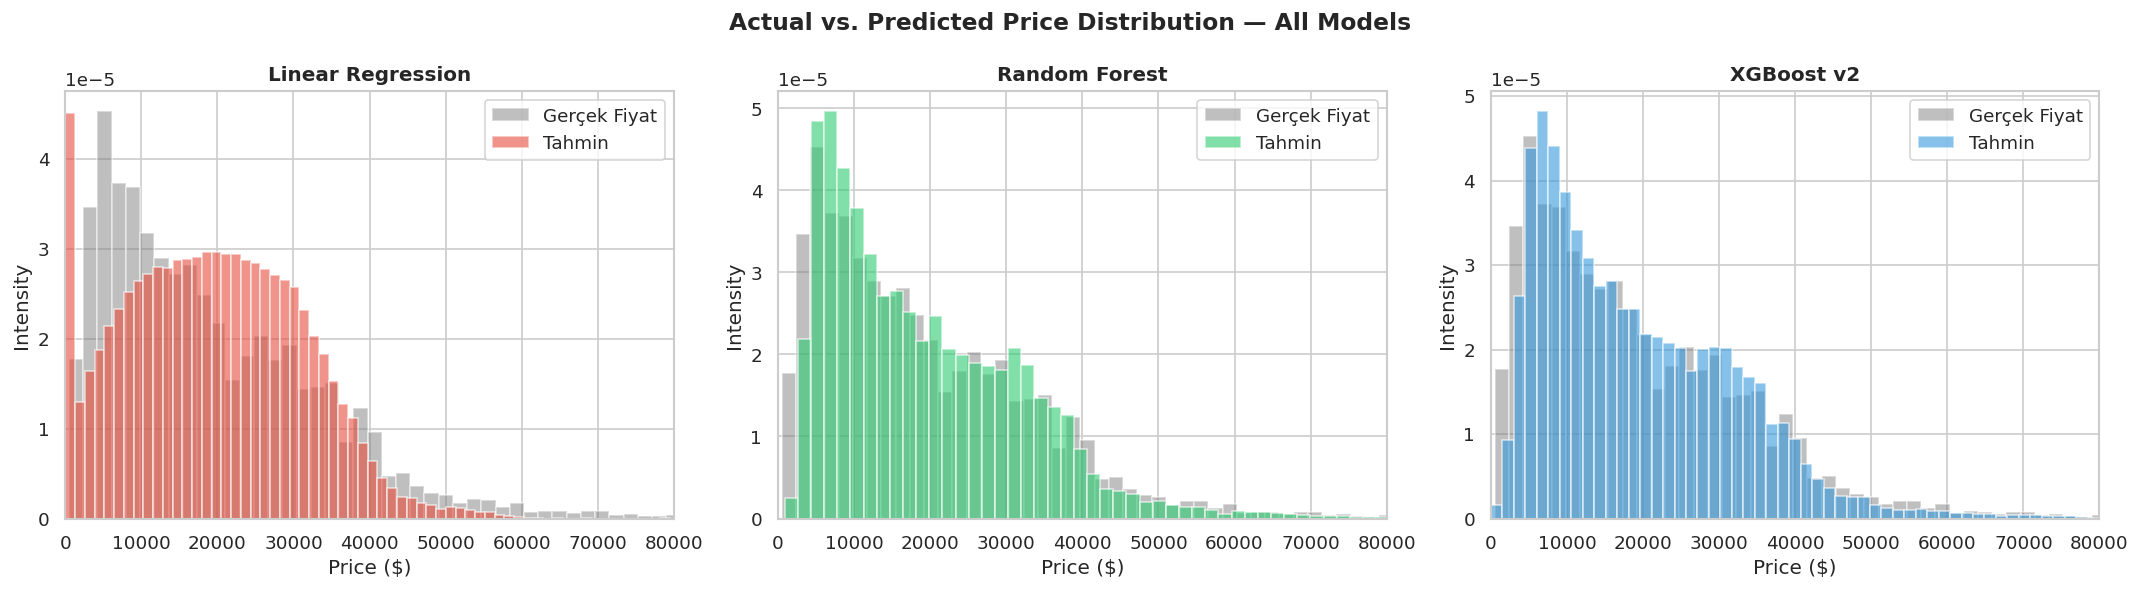

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Linear Regression', y_pred_lr,     '#e74c3c'),
    ('Random Forest',     y_pred_rf,     '#2ecc71'),
    ('XGBoost v2',        y_pred_xgb_v2, '#3498db')
]

y_test_arr = np.array(y_test)

for ax, (name, y_pred, color) in zip(axes, models_info):
    y_pred_arr = np.array(y_pred)

    # Reduce negative predictions to 0 (for LR)
    y_pred_clipped = np.clip(y_pred_arr, 0, 150000)

    ax.hist(y_test_arr, bins=80, alpha=0.5,
            color='gray', label='Gerçek Fiyat', density=True)
    ax.hist(y_pred_clipped, bins=80, alpha=0.6,
            color=color, label='Tahmin', density=True)

    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Price ($)')
    ax.set_ylabel('Intensity')
    ax.legend()
    ax.set_xlim(0, 80000)

plt.suptitle('Actual vs. Predicted Price Distribution — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## **STREAMLIT**

https://carpricepredictionml-2mpvpkbts7anloh5kaw6c8.streamlit.app/